# Email Research Assistant

### Imports

In [3]:
import requests
import json
from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAI
import os
from pydantic import BaseModel, Field
from typing import List, Dict, Any, Literal, Annotated, Optional
from langchain_core.prompts import ChatPromptTemplate
import pathlib
from bs4 import BeautifulSoup
import re
from typing_extensions import TypedDict, Union
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from __future__ import print_function
import sib_api_v3_sdk
from sib_api_v3_sdk.rest import ApiException
from IPython.display import Markdown, display
import google.generativeai as genai
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.checkpoint.memory import MemorySaver



## Searching Google & Filtering Results

In [28]:
# # general function for loading prompt md file, just give file name while calling this function
from modules.search_relevance import check_search_relevance
from graphs.user_search_terms import user_input_search_terms
from prompts.prompt_loader import load_prompt

# # it will get web results using serper
from web_search.serper import search_serper

  # to store result after filtering the raw serper result through check_search_relevance function
# from modules.search_relevance import check_search_relevance

# # general template for loading prompt md file, just give file name while calling this function
prompt = load_prompt("./prompts/relevance_check.md")
print(f"prompt template {prompt}")

#each item of this list will be passed as argument in a for loop created below.
# search_terms = ["Agents development in 2025", "Production ready AI Agents", "best fields to make AI Agents for"]

# # Functions calling start from here...

#below is the variable created to have the final result
relevant_results = []

# user seach terms
search_terms = user_input_search_terms()

# below for loop will call the above created functions
for search_term in search_terms: # this loop will be executed n times search_terms[n*]

    # to get raw results received from serper
    python_results = search_serper(search_term) # search_terms variable is created above which contain list of required searching keywords or terms.
    # print(type(python_results))

    # to store result after filtering the raw serper result through check_search_relevance function
    results = check_search_relevance(python_results, prompt)
    # print(f"llm response {results}")
    relevant_data = results['relevant_results']
    # print(len(relevant_data))
    # print(relevant_data)
    
    # all_results = []
    # for relevant_result in relevant_data:    
    #     result_dict = {
    #         "id": relevant_result['id']
    #     }
    #     all_results.append(result_dict)

    relevant_ids = []
    # [{'id': '3'}, {'id': '4'}, {'id': '1'}, {'id': '2'}]

    for relevant_result in relevant_data:    
        # result_dict = {
        #     "id": relevant_result['id']
        # }
        relevant_ids.append(relevant_result['id'])
    # print(relevant_ids)

    # Filter original results ot only include those with matching IDs
    filtered_results = [r for r in python_results if str(r['id']) in relevant_ids]
    relevant_results.extend(filtered_results)
# print(f"filtered_results {relevant_results}") 
# filtered_results [{'title': 'What is Agentic AI? Important For GEN AI In 2025 - YouTube', 'link': 'https://www.youtube.com/watch?v=xOS0BhhdUbo', 'snippet': 'Agentic AI, or AI agents, are software systems that can perform tasks autonomously with minimal human intervention. They are designed to be goal-oriented ...', 'search_term': 'Agentic AI', 'id': 1}, 

for final_result in relevant_results:
    result_dict = {
            'title': final_result['title'],
            'link' : final_result['link'],
            'snippet' : final_result['snippet'],
            'search_term': final_result['search_term']
            }
    print(result_dict)


prompt template # Role

You are a research assistant who is working for a busy CTO.

# Context

The CTO is trying to stay up to date with latest news and information around particular topics.

# Task

You are searching through google, and trying to determine which links are potentialy relevant and worth exploring further.

You will be asked to review search results and to determine if they are relevant to explore further, or if they are not relevant.

You will be given a list of search results, and you will need to determine which 5 are most relevant, and detail why.

# Example of what is relevant 


- Agentic AI updates from the large AI players:
-- OpenAI
-- Meta
-- Perplexity
-- Gemini
-- Mistral
-- Cursor
- How people are using agents in industry, from LinkedIn, Twitter, etc.
- News articles about AI agents.

# Example of what is not relevant 

- Startup blogs that are likley for marketing purposes
- Technical Blog that isnt an industry use case or update
- Don't mention youtube

#

TypeError: check_search_relevance() takes 1 positional argument but 2 were given

In [ ]:
prompt = load_prompt("./prompts/relevance_check.md")
print(f"prompt template {prompt}")

## Scrape & Convert to Markdown

In [5]:
def convert_html_to_markdown(html_content):
    # Create BeautifulSoup object
    soup = BeautifulSoup(html_content, 'html.parser')

    # Convern common HTML elements to markdown

    # Headers
    for h in soup.find_all(['h1', 'h2', 'h3', 'h4', 'h5', 'h6']):
        level = int(h.name[1])
        h.replace_with('#' * level + ' ' + h.get_text() + '\n\n')

    # Links
    for a in soup.find_all('a'):
        href = a.get('href', '')
        text = a.get_text()
        if href and text:
            a.replace_with(f'[{text}]({href})')
    
    # Bold
    for b in soup.find_all('b', 'strong'):
        b.replace_with(f'**{b.get_text()}**')
    
    # Italic
    for i in soup.find_all('i', 'em'):
        i.replace_with(f'*{i.get_text()}*')
    
    # List
    for ul in soup.find_all('ul'):
        for li in ul.find_all('ul'):
            li.replace_with(f'- {li.get_text()}\n')
    
    for ol in soup.find_all('ol'):
        for i, li in enumerate(ol.find_all('li'), 1):
            li.replace_with(f'{i}. {li.get_text()}\n')
    
    # Get text and clean up
    text = soup.get_text()

    # Remove excess whitespace/newlines
    text = re.sub(r'\n\s*\n', '\n\n', text)
    text = text.strip()

    return text

ts_markdown_contents = ""
def scrape_and_save_markdown(relevant_results):
    """
    Scrapes HTML content from URLs in relevant_results and saves as markdown files.
    
    Args:
        relevant_results:List of dictionaries containing seach results with URLs

    Returns:
        List of dictionaries containing markdown content and metadata
    """
    # Create scraped_html directory if it doesn't exist
    pathlib.Path("scraped_markdown").mkdir(exist_ok=True)

    markdown_contents = []
    for result in relevant_results:
        print(f"result data {result}")
        if 'link' in result:
            print(f"link in result is {result["link"]}")
            headers = { "apikey": "23cb8640-c378-11ef-ba1d-61453f751c6d"} #ZENSCRAPE_API_KEY = "52227bb4ce11d45935ad38a980f15b234de6cf6d"
            params = (
            ("url", result["link"]),
            ("render","true"),
            )
            
            response = requests.get('https://app.zenscrape.com/api/v1/get', headers=headers, params=params)
            print(f"scraping res = {response.text}")
            if response.status_code == 200:
                # Create filename from ID or URL if ID not available
                filename = f"{result.get('id', hash(result['link']))}.md"
                filepath = os.path.join("scraped_markdown", filename)
                
                # Convert HTML to markdown
                markdown_content = convert_html_to_markdown(response.content.decode()) # org .content.decode()

                # Save markdown content to file
                with open(filepath, 'w', encoding='utf-8') as f:
                    f.write(markdown_content)
                
                markdown_contents.append({
                    'url' : result['link'],
                    'filepath' : filepath,
                    'Markdown' : markdown_content,
                    'title' : result.get('title', ''),
                    'id' : result.get('id', '')
                })
            else:
                print(f"Failed to fetch {result['link']}: Status code {response.status_code}")
            
    print(f"Successfully downloaded and saved {len(markdown_contents)} pages as markdown to scraped_markdown/")
    return markdown_contents
    
markdown_contents = scrape_and_save_markdown(relevant_results)
ts_markdown_contents = markdown_contents

print(markdown_contents)

result data {'title': 'Kevin Petrie - ai #data #genai #llm - LinkedIn', 'link': 'https://www.linkedin.com/posts/kevinpetrietech_ai-data-genai-activity-7282749532390498304-5Umf', 'snippet': 'I find this fascinating... new metrics from LangChain show rising user adoption and sophistication of agentic AI. Agentic AI loosely refers to workflows that…', 'search_term': 'linkedIn Agentic AI Project', 'id': 'GNMJNYCBSUCQ'}
link in result is https://www.linkedin.com/posts/kevinpetrietech_ai-data-genai-activity-7282749532390498304-5Umf
scraping res = <!DOCTYPE html>

    
    
    
    
    
    
    
    
    
    
    
    
    
    
    

    
    <html lang="en">
      <head>
        <meta name="pageKey" content="d_public_post">
<!----><!---->        <meta name="locale" content="en_US">
        <meta id="config" data-app-version="1.2.847" data-call-tree-id="AAYrP4mtj9HvcT8ry3blag==" data-multiproduct-name="feedcontent-guest-frontend" data-service-name="feedcontent-guest-frontend" data-browse

## Generate Summaries of Markdown

In [6]:
# def generate_summaries(markdown_contents):
#     """
#     Generates summaries for markdown content using Gemini.

#     Args:
#         markdown_contents: List of dictionaries containing markdown content and metadata
    
#     Returns:
#         List of dictionaries containing summaries and URLs

#     """
#     # Create markdown_summaries directory if it doesn't exist
#     pathlib.Path('markdown_summaries').mkdir(exist_ok=True)

#     # Load the summary prompt
#     summary_prompt = load_prompt("summarise_markdown_page")

    

In [7]:
from random import choice
from string import ascii_uppercase

# class Markdown_summary(BaseModel):
#     summary : str


# class Markdown_summaries(BaseModel):
#     markDown_summaries : List[Markdown_summary]

def generate_summaries(markdown_contents):
    """
    Generates summaries for markdown content using GPT-4.
    
    Args:
        markdown_contents: List of dictionaries containing markdown content and metadata
        
    Returns:
        List of dictionaries containing summaries and URLs
    """
    # Create markdown_summaries directory if it doesn't exist
    pathlib.Path("markdown_summaries").mkdir(exist_ok=True)

    # Load the summary prompt
    summary_prompt = load_prompt("summarise_markdown_page")

    # # Create prompt template
    # summary_template = ChatPromptTemplate.from_messages([
    #     ("system", summary_prompt)
    # ])

        
    # summary_chain = summary_template | llm

    # Generate and save summaries
    summaries = []
    for content in markdown_contents:
        print(f"content = {content}")
        # print(f"content = {content["Markdown"]}")
        try:            
            # # Generate summary, limiting to first 2000 words
            summary = client.beta.chat.completions.parse(
            model="gemini-1.5-flash",
            messages=[
                {"role": "system", "content": f"{summary_prompt}"},
                {"role": "user", "content": f"{content["Markdown"]}"},
                ],
                # response_format=Markdown_summaries
            )
            # print(f"summary created by llm = {summary.choices[0].message.content}")
            # summaries.append(summary.choices[0].message.content)
    
            
    # #         # Create filename for summary
            summary_filename = f"summary_{content['id']}.md"
            print(summary_filename)
            summary_filepath = os.path.join("markdown_summaries", summary_filename)
            
    # #         # Save summary to file
            with open(summary_filepath, 'w', encoding='utf-8') as f:
                f.write(summary.choices[0].message.content)
            
    # #         # Add to summaries list
            summaries.append({
                'markdown_summary': summary.choices[0].message.content,
                'url': content["url"]
            })
            print(f"data inserted in summaries {summaries}")
                
        except Exception as e:
            print(f"Failed to summarize {content['filepath']}: {str(e)}")
    print(f"Successfully generated summaries for {len(summaries)} pages in markdown_summaries/")
    return summaries


summaries_calling = generate_summaries(markdown_contents)


content = {'url': 'https://www.linkedin.com/posts/kevinpetrietech_ai-data-genai-activity-7282749532390498304-5Umf', 'filepath': 'scraped_markdown\\GNMJNYCBSUCQ.md', 'Markdown': 'Kevin Petrie on LinkedIn: #ai #data #genai #llm\n\n              Agree & Join LinkedIn\n\n      By clicking Continue to join or sign in, you agree to LinkedIn’s [User Agreement](/legal/user-agreement?trk=linkedin-tc_auth-button_user-agreement), [Privacy Policy](/legal/privacy-policy?trk=linkedin-tc_auth-button_privacy-policy), and [Cookie Policy](/legal/cookie-policy?trk=linkedin-tc_auth-button_cookie-policy).\n\n[\n      Skip to main content\n    ](#main-content)\n\n[\nLinkedIn\n\n](/?trk=public_post_nav-header-logo)\n\n[\n\n        Articles\n\n](https://www.linkedin.com/pulse/topics/home/?trk=public_post_guest_nav_menu_articles)\n\n[\n\n        People\n\n](https://www.linkedin.com/pub/dir/+/+?trk=public_post_guest_nav_menu_people)\n\n[\n\n        Learning\n\n](https://www.linkedin.com/learning/search?trk=publ

In [8]:
print(summaries_calling[0]['markdown_summary'])

## Summary of Kevin Petrie's LinkedIn Post on Agentic AI

Kevin Petrie, Vice President of Research at BARC, shared a LinkedIn post discussing the rising adoption and sophistication of agentic AI, based on new metrics from LangChain.  The post highlights LangChain's LangGraph framework, a controllable agent framework used to design, develop, and orchestrate GenAI-assisted workflows.  Petrie notes that while the hype surrounding AI agents might exceed their current capabilities (human oversight is often still needed), they represent a significant advancement in software automation.  He also emphasizes their potential to generate profitable use cases for large language models (LLMs), whose training costs billions for companies like OpenAI, Google, and Microsoft.

**Key Findings from LangChain's Report:**

* **Increased Adoption of LangGraph:**  Since its March 2024 release, 43% of LangSmith organizations are using LangGraph, indicating a growing seriousness in incorporating AI agents acro

## LangGraph Email Summary & Review

## Graph State

In [10]:
class State(TypedDict):
    messages: Annotated[List, add_messages]
    summaries: List[dict]
    approved: bool
    created_summaries: Annotated[List[dict], Field(description="The summaries that have been created by the summariser")]
graph_builder = StateGraph(State)

## Summariser Node

In [10]:
# # # Load templates and prompts
# with open("email_template.md", "r") as f:
#     emails_template = f.read()

# class SummarieseOutPut(BaseModel):
#     email_summary: str = Field(description="The summary email of the content")
#     message: str = Field("A message to the reviewer, asking for feedback on the summary")

# summariser_prompt = 

In [11]:
from langchain_core.messages import AIMessage

llm = ChatGoogleGenerativeAI(
    model="gemini-1.5-flash",
    max_retries=2,
    api_key = gemini_api_key
)

# Load templates and prompts
with open("email_template.md", "r") as f:
    email_template = f.read()

prompt = load_prompt("summariser")

class SummariserOutput(BaseModel):
    f"""{prompt}"""
    email_summary: str = Field(description="The summary email of the content")
    message: str = Field(description="A message to the reviewer, asking for feedback on the summary")

summariser_prompt_input = ChatPromptTemplate.from_messages([
    ("system", load_prompt("summariser")),
    ("placeholder", "{messages}"),
])

summariser_prompt = summariser_prompt_input

# # print(f" search_result {search_results}")
# completion = client.beta.chat.completions.parse(
# model="gemini-1.5-flash",
# messages=[
#     {"role": "system", "content": f"{prompt}"},
#     {"role": "user", "content": f"{search_results}"},
# ],
# response_format=SummariserOutput)
# # print(completion.choices[0].message.parsed)
# # print(f"Gemini response after processing search_results {completion.choices[0].message.content}")
# # Access the list of relevant results
# selected_by_llm = completion.choices[0].message.content
# results = json.loads(selected_by_llm) 

# return results



llm_summariser = summariser_prompt_input | llm.with_structured_output(SummariserOutput)

def summariser(state: State):
    summariser_output = llm_summariser.invoke({"messages": state["messages"], "summaries": state["summaries"], "input_template": email_template})
    new_messages = [AIMessage(content=summariser_output.email_summary), AIMessage(content=summariser_output.message)]
    return {"messages": new_messages, "created_summaries": [summariser_output.email_summary]}
data = summariser({"messages" : [HumanMessage(content=summariser_prompt.messages[0].prompt.template)],"summaries" : summaries_calling})
# print(summariser_prompt.messages[0].prompt.template)

NameError: name 'load_prompt' is not defined

In [12]:
print(data)
# summariser_prompt = ChatPromptTemplate.from_messages([
#     ("system", load_prompt("summariser")),
#     ("placeholder", "{messages}"),
# ])
# print(summariser_prompt)

NameError: name 'data' is not defined

In [13]:
# summariser_prompt = ChatPromptTemplate([
#     # ("system", load_prompt("summariser")),
#     ("placeholder", "{messages}"),
# ])
# # print(summariser_prompt)

# llm = ChatGoogleGenerativeAI(
#     model="gemini-1.5-flash",
#     max_retries=2,
#     api_key = gemini_api_key
# )


# chain = summariser_prompt | llm
# print(chain)

In [14]:
class ReviewerOutput(BaseModel):
    approved: bool = Field(description="Whether the summary is approved or not")
    message: str = Field(description="A message to the reviewer, asking for feedback on the summary")

reviewer_prompt = ChatPromptTemplate.from_messages([
    ("system", load_prompt("reviewer")),
    ("placeholder", "{messages}"),
])


llm_reviewer = reviewer_prompt | llm.with_structured_output(ReviewerOutput)

def reviewer(state: State):
    # Convert AIMessages to HumanMessages and vice versa
    converted_messages = []
    for msg in state["messages"]:
        if isinstance(msg, AIMessage):
            converted_messages.append(HumanMessage(content=msg.content))
        elif isinstance(msg, HumanMessage):
            converted_messages.append(AIMessage(content=msg.content))
        else:
            converted_messages.append(msg)
    state["messages"] = converted_messages
    reviewer_output = llm_reviewer.invoke({"messages": state["messages"]})
    new_messages = [HumanMessage(content=reviewer_output.message)]
    return {"messages": new_messages, "approved": reviewer_output.approved}

## Build the Graph

In [13]:
def conditional_edge(state: State) -> Literal["summariser", END]:
    if state["approved"]:
        return END
    else:
        return "summariser"


# Create and configure the graph
graph_builder.add_node("summariser", summariser)
graph_builder.add_node("reviewer", reviewer)
graph_builder.add_edge(START, "summariser")
graph_builder.add_edge("summariser", "reviewer")
graph_builder.add_conditional_edges('reviewer', conditional_edge)

# Memory
memory: MemorySaver = MemorySaver()

# Compile and run the graph
graph = graph_builder.compile(checkpointer=memory)

NameError: name 'summariser' is not defined

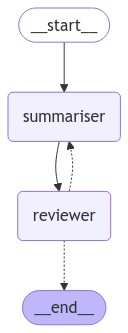

In [16]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

In [17]:
output = graph.invoke({"messages": [HumanMessage(content=summariser_prompt.messages[0].prompt.template)],"summaries": summaries_calling})

In [21]:
final_summary = output["created_summaries"][-1]
display(Markdown(final_summary))

<h1>Big Company Updates</h1>\n<h2>Key Highlights</h2>\n<ul><li>LangChain's LangGraph adoption is surging, indicating a serious move towards sophisticated AI agents.</li><li>AI agents are evolving to handle increasingly complex, multi-step tasks autonomously.</li><li>While promising,  human oversight remains critical in the current state of AI agent development.</li><li>Businesses are discovering profitable applications for LLMs via AI agents, unlocking new value.</li><li>The field is actively debating the precise definition of 'agentic' AI, highlighting ongoing development.</li></ul>\n<h2>Deeper Dive</h2>\n<h3>LangChain's Growing Influence</h3>\n<p>Kevin Petrie's LinkedIn post reveals a significant increase in LangChain's LangGraph adoption.  43% of LangSmith organizations are now using it, showcasing a clear trend towards more complex AI workflows. The average number of steps per workflow has more than doubled, highlighting the rise of autonomous, multi-step processes.  Importantly, LLM calls per workflow haven't exploded, suggesting optimized use of these expensive resources.</p>\n<h3>Defining Agentic AI: A Work in Progress</h3>\n<p>Chenxi Wang's post adds an essential layer to the discussion by clarifying the definition of 'agentic' AI.  She distinguishes between true agentic systems, capable of autonomous problem-solving, and simpler applications that merely use LLMs.  The post sparked a lively discussion on LinkedIn, highlighting the need for more precise terminology and a deeper understanding of this evolving technology.  A key takeaway is the importance of distinguishing genuine capabilities from hype.</p>\n<p>In short, the AI agent landscape is dynamic.  We're seeing more sophisticated, autonomous agents, but clear definitions and human oversight remain crucial.  The potential for profitable LLM applications is undeniable.</p>\n<p><a href=\"https://www.linkedin.com/posts/kevinpetrietech_ai-data-genai-activity-7282749532390498304-5Umf\">Kevin Petrie's LinkedIn post on LangChain's LangGraph adoption</a></p>\n<p><a href=\"https://www.linkedin.com/posts/chenxiwang88_ai-agent-hackathon-activity-7282777674198982656-VLiD\">Chenxi Wang's LinkedIn post on defining 'agentic' AI</a></p>\n<h1>Industry Trends</h1>\n<h2>Key Highlights</h2>\n<ul><li>The rapid rise of AI agents signifies a pivotal shift in automation and workflow design.</li><li>Improved efficiency and complexity in AI-driven processes are transforming industries.</li><li>The ongoing debate around 'agentic' AI emphasizes the need for clear definitions and responsible development.</li><li>Despite increased automation, human oversight and ethical considerations remain paramount.</li><li>The convergence of AI agents and LLMs presents significant opportunities for innovation and profitability.</li></ul>\n<h2>Deeper Dive</h2>\n<h3>The Transformative Power of AI Agents</h3>\n<p>The combined insights from Petrie and Wang's posts reveal a significant shift in the AI landscape.  AI agents are no longer a niche technology; they are rapidly becoming mainstream, driving efficiency gains and enabling more complex workflows.  This trend demands attention from businesses and policymakers alike.</p>\n<h3>Navigating the Agentic AI Frontier</h3>\n<p>The ongoing discussion surrounding the definition of 'agentic' AI underscores the importance of responsible innovation. While the potential benefits are immense, it is crucial to establish clear guidelines and standards to ensure the ethical and safe deployment of these powerful technologies.  The future of work and various industries hinges on navigating this frontier wisely.</p>\n<p>In essence, the rapid evolution of AI agents presents both immense opportunities and considerable challenges.  Staying informed and proactive is essential for navigating this transformative technological shift.</p>

In [19]:
print(output)
# final_summary = output["created_summaries"][-1]

# display(Markdown(final_summary))

{'messages': [HumanMessage(content='# Role\n\nYou are a research assistant who is working for a busy CTO.\n\n# Task\n\nYou are given a list of summaries of online articles, and their links, and you need to provide a summary email of the content. You need to make sure that the summary is comprehensive, light hearted, and easy to read. You should also include emojis to make it easier to read. You should also include links to the original articles.\n\nYou also need to send a message to the reviewer, asking for feedback on the summary. The reviewer will decide if the summary is approved or not. If not, you will need to provide a new summary.\n\n# Output Format\n\nYou need to provide an output summary in html format, following this markdown template (note that the template is in markdown format, but the output should be in html format):\n\n```markdown\n{input_template}\n```\n\nThe deep dive section should be significantly more detailed than the high level summary section.\n\n# Input Summari

In [20]:
reviewer_prompt = ChatPromptTemplate.from_messages([
    ("system", load_prompt("summariser")),
    ("placeholder", "{messages}"),
])

my_prompt = reviewer_prompt.invoke({'summaries' : summaries_calling, 'input_template' : email_template }) | 
print(my_prompt.messages[0].content)



SyntaxError: invalid syntax (2307159342.py, line 6)

In [44]:
print(my_prompt)

messages=[SystemMessage(content='# Role\n\nYou are a research assistant who is working for a busy CTO.\n\n# Task\n\nYou are given a list of summaries of online articles, and their links, and you need to provide a summary email of the content. You need to make sure that the summary is comprehensive, light hearted, and easy to read. You should also include emojis to make it easier to read. You should also include links to the original articles.\n\nYou also need to send a message to the reviewer, asking for feedback on the summary. The reviewer will decide if the summary is approved or not. If not, you will need to provide a new summary.\n\n# Output Format\n\nYou need to provide an output summary in html format, following this markdown template (note that the template is in markdown format, but the output should be in html format):\n\n```markdown\n# Big Company Updates\n\n## Key Highlights\n\n- Highlight 1:\nShort description\n- Highilight 2\nShort desctiption\n- Highlight 3\nShort descri